In [44]:
# Crypto Price Prediction Neural Network
# Predicting min/max prices for future candles using historical data

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Configuration
CSV_PATH = "/Users/dyodio/Documents/Projects/Finance-Smash/data/crypto/ETH-USDT/5min.csv"  # Path to your crypto data
P = 300  # Number of previous candles to use for prediction
F = 20   # Number of future candles to predict min/max for
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 100
TRAIN_SPLIT = 0.8

print("Configuration:")
print(f"Data path: {CSV_PATH}")
print(f"Previous candles (P): {P}")  
print(f"Future candles (F): {F}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {EPOCHS}")


Configuration:
Data path: /Users/dyodio/Documents/Projects/Finance-Smash/data/crypto/ETH-USDT/5min.csv
Previous candles (P): 300
Future candles (F): 20
Batch size: 32
Learning rate: 0.001
Epochs: 100


In [66]:
# Load and explore the data
def load_crypto_data(csv_path):
    """Load crypto data from CSV file"""
    df = pd.read_csv(csv_path)
    print(f"Loaded data shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Date range: {df['Gmt time'].iloc[0]} to {df['Gmt time'].iloc[-1]}")
    
    # Convert timestamp to datetime
    df['Gmt time'] = pd.to_datetime(df['Gmt time'])
    
    # Sort by time to ensure chronological order
    df = df.sort_values('Gmt time').reset_index(drop=True)
    
    return df

# Load the data
df = load_crypto_data(CSV_PATH)[0:300000]

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

# Display basic statistics
print("\nBasic statistics:")
print(df.describe())


Loaded data shape: (755150, 6)
Columns: ['Gmt time', 'Open', 'High', 'Low', 'Close', 'Volume']
Date range: 2017-08-21 00:00:00 to 2024-10-31 00:00:00

First 5 rows:
             Gmt time    Open    High     Low   Close    Volume
0 2017-08-21 00:00:00  299.10  299.10  297.51  297.51  32.28933
1 2017-08-21 00:05:00  297.51  300.52  295.76  299.03  94.60123
2 2017-08-21 00:10:00  296.12  299.03  296.12  299.02  21.48930
3 2017-08-21 00:15:00  299.02  299.03  296.13  297.61  19.62946
4 2017-08-21 00:20:00  299.03  300.53  297.61  297.71  18.85684

Basic statistics:
                            Gmt time           Open           High  \
count                         300000  300000.000000  300000.000000   
mean   2019-01-26 18:09:15.011000320     313.787917     314.548784   
min              2017-08-21 00:00:00      82.120000      82.200000   
25%              2018-05-10 06:53:45     168.230000     168.490000   
50%              2019-01-26 22:42:30     222.900000     223.330000   
75%         

Creating sequences and targets...
Input shape (X): (299681, 300, 5)
Target shape (y): (299681, 2)
Total samples: 299681

Sample input shape: (300, 5)
Sample target: min=301.4000, max=325.0700


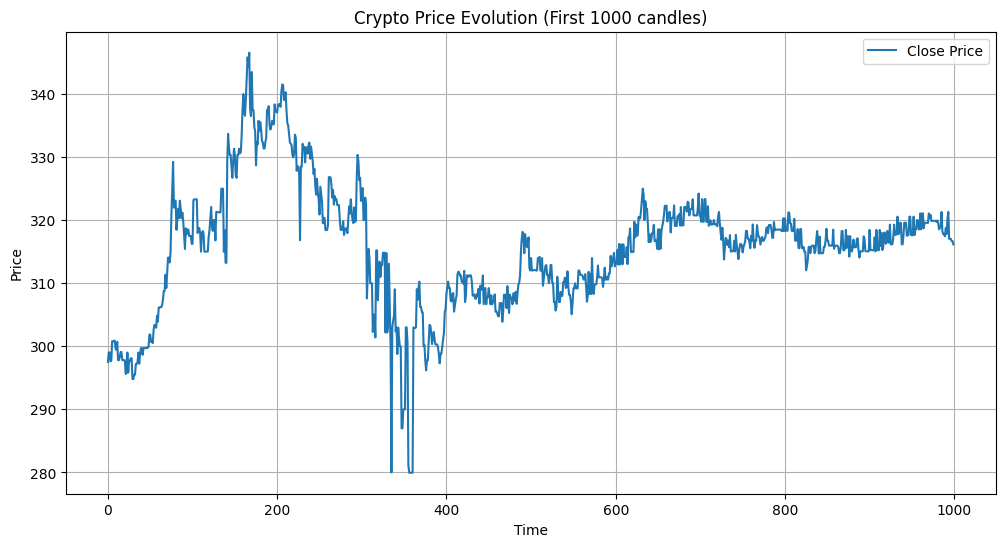

In [67]:
# Data preprocessing
def create_sequences_and_targets(df, p_candles, f_candles):
    """
    Create sequences of P previous candles and targets of min/max for F future candles
    
    Args:
        df: DataFrame with OHLCV data
        p_candles: Number of previous candles to use as input
        f_candles: Number of future candles to predict min/max for
        
    Returns:
        X: Input sequences (samples, sequence_length, features)
        y: Target values (samples, 2) - [min_price, max_price] over F future candles
    """
    # Use OHLCV as features
    features = ['Open', 'High', 'Low', 'Close', 'Volume']
    data = df[features].values
    
    X, y = [], []
    
    # We need at least p_candles + f_candles data points
    for i in range(p_candles, len(data) - f_candles + 1):
        # Input: P previous candles
        X.append(data[i-p_candles:i])
        
        # Target: min and max prices over F future candles
        future_data = data[i:i+f_candles]
        future_lows = future_data[:, 2]  # Low prices (index 2)
        future_highs = future_data[:, 1]  # High prices (index 1)
        
        min_price = np.min(future_lows)
        max_price = np.max(future_highs)
        
        y.append([min_price, max_price])
    
    return np.array(X), np.array(y)

# Create sequences and targets
print("Creating sequences and targets...")
X, y = create_sequences_and_targets(df, P, F)

print(f"Input shape (X): {X.shape}")  # Should be (samples, P, 5)
print(f"Target shape (y): {y.shape}")  # Should be (samples, 2)
print(f"Total samples: {len(X)}")

# Visualize a sample
print(f"\nSample input shape: {X[0].shape}")
print(f"Sample target: min={y[0][0]:.4f}, max={y[0][1]:.4f}")

# Plot price evolution over time
plt.figure(figsize=(12, 6))
plt.plot(df['Close'][:1000], label='Close Price')
plt.title('Crypto Price Evolution (First 1000 candles)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def normalize_data_per_sample(X, y, train_split=0.8):
    """
    Per-sample normalization approach:
    - Each sample (P candles) normalized by its own min/max
    - Target (F future candles) normalized by the same P candles min/max
    - Model learns relative patterns within each sequence
    - Robust to new price levels not seen in training
    """
    # Split data chronologically
    split_idx = int(len(X) * train_split)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    print(f"Train samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    
    def normalize_sample_wise(X_data, y_data):
        """Normalize each sample independently"""
        X_normalized = np.zeros_like(X_data)
        y_normalized = np.zeros_like(y_data)
        scalers_info = []  # Store scaling info for later inverse transform
        
        for i in range(len(X_data)):
            # Get the i-th sample (P candles)
            sample_X = X_data[i]  # Shape: (P, 5)
            sample_y = y_data[i]  # Shape: (2,) = [min_price, max_price]
            
            # Separate OHLC and Volume
            sample_prices = sample_X[:, :4]  # OHLC of P candles
            sample_volume = sample_X[:, 4:5]  # Volume of P candles
            
            # Price normalization: use min/max from the P candles OHLC
            price_min = sample_prices.min()
            price_max = sample_prices.max()
            
            if price_max > price_min:  # Avoid division by zero
                # Normalize OHLC using local min/max
                sample_prices_norm = (sample_prices - price_min) / (price_max - price_min)
                
                # Normalize targets using SAME local price min/max
                sample_y_norm = (sample_y - price_min) / (price_max - price_min)
            else:
                # Handle edge case where all prices are the same
                print("EDGE CASE PRICES")
                sample_prices_norm = np.zeros_like(sample_prices)
                sample_y_norm = np.array([0.0, 0.0])
            
            # Volume normalization: use min/max from the P candles volume
            volume_min = sample_volume.min()
            volume_max = sample_volume.max()
            
            if volume_max > volume_min:
                sample_volume_norm = (sample_volume - volume_min) / (volume_max - volume_min)
            else:
                print("EDGE CASE VOLUME")
                sample_volume_norm = np.ones_like(sample_volume) * 0.0
            
            # Combine normalized features
            X_normalized[i] = np.concatenate([sample_prices_norm, sample_volume_norm], axis=1)
            y_normalized[i] = sample_y_norm
            
            # Store scaling parameters for inverse transform
            scalers_info.append({
                'price_min': price_min,
                'price_max': price_max,
                'volume_min': volume_min,
                'volume_max': volume_max
            })
        
        return X_normalized, y_normalized, scalers_info
    
    print("Normalizing training data (per-sample)...")
    X_train_norm, y_train_norm, train_scalers = normalize_sample_wise(X_train, y_train)
    
    print("Normalizing test data (per-sample)...")
    X_test_norm, y_test_norm, test_scalers = normalize_sample_wise(X_test, y_test)
    
    # Verify normalization
    print(f"\nNormalization verification:")
    print(f"X_train range: [{X_train_norm.min():.3f}, {X_train_norm.max():.3f}]")
    print(f"y_train range: [{y_train_norm.min():.3f}, {y_train_norm.max():.3f}]")
    print(f"X_test range: [{X_test_norm.min():.3f}, {X_test_norm.max():.3f}]")
    print(f"y_test range: [{y_test_norm.min():.3f}, {y_test_norm.max():.3f}]")
    
    return (X_train_norm, X_test_norm, y_train_norm, y_test_norm, 
            train_scalers, test_scalers)

# Use per-sample normalization
print("Using per-sample normalization for better generalization...")
X_train, X_test, y_train, y_test, train_scalers, test_scalers = normalize_data_per_sample(X, y, TRAIN_SPLIT)

print(f"\nFinal shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print(f"\n Sample X_train")


Using per-sample normalization for better generalization...
Train samples: 239744
Test samples: 59937
Normalizing training data (per-sample)...
Normalizing test data (per-sample)...

Normalization verification:
X_train range: [0.000, 1.000]
y_train range: [-4.662, 4.840]
X_test range: [0.000, 1.000]
y_test range: [-4.647, 3.277]

Final shapes:
X_train: (239744, 300, 5)
X_test: (59937, 300, 5)
y_train: (239744, 2)
y_test: (59937, 2)

 Sample X_train
[[0.0866718  0.0866718  0.05604777 0.05604777 0.20624121]
 [0.05604777 0.11402157 0.02234206 0.08532357 0.60424518]
 [0.02927581 0.08532357 0.02927581 0.08513097 0.13725832]
 ...
 [0.63674884 0.63674884 0.6107473  0.6107473  0.1047911 ]
 [0.64040832 0.66872111 0.61825886 0.61825886 0.22268426]
 [0.61594761 0.6683359  0.54776579 0.54776579 0.28712617]]

 Sample X_test
[[0.41687345 0.42431762 0.3573201  0.39454094 0.01179643]
 [0.38957816 0.4516129  0.34739454 0.36476427 0.03241548]
 [0.36476427 0.37468983 0.27543424 0.29280397 0.0072404 ]
 ..

In [69]:
# PyTorch Dataset class
class CryptoDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets and data loaders
train_dataset = CryptoDataset(X_train, y_train)
test_dataset = CryptoDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Created datasets:")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of train batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

# Test data loader
sample_batch_X, sample_batch_y = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"X batch: {sample_batch_X.shape}")
print(f"y batch: {sample_batch_y.shape}")


Created datasets:
Train dataset size: 239744
Test dataset size: 59937
Number of train batches: 7492
Number of test batches: 1874

Sample batch shapes:
X batch: torch.Size([32, 300, 5])
y batch: torch.Size([32, 2])


In [70]:
# Neural Network Model
class CryptoPricePredictor(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, output_size=2, dropout=0.2):
        super(CryptoPricePredictor, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.fc3 = nn.Linear(hidden_size // 4, output_size)
        
        # Dropout and activation
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # LSTM forward pass
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Use the last output of the sequence
        last_output = lstm_out[:, -1, :]
        
        # Fully connected layers
        out = self.relu(self.fc1(last_output))
        out = self.dropout(out)
        out = self.relu(self.fc2(out))
        out = self.dropout(out)
        out = self.fc3(out)
        
        return out

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

model = CryptoPricePredictor(
    input_size=5,  # OHLCV features
    hidden_size=64,
    num_layers=2,
    output_size=2,  # min_price, max_price
    dropout=0.2
).to(device)

# Print model architecture
print(f"\nModel architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\nTraining setup:")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
print(f"Learning rate: {LEARNING_RATE}")


Using device: mps

Model architecture:
CryptoPricePredictor(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=2, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)

Total trainable parameters: 54,098

Training setup:
Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning rate: 0.001


In [ ]:
# Training function
from tqdm import tqdm

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, device):
    """Train the neural network model"""
    train_losses = []
    test_losses = []
    
    print("Starting training...")
    print("-" * 50)
    total_train_batches = len(train_loader)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        print(f"Epoch {epoch+1}/{epochs}")
        
        for batch_X, batch_y in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", total=total_train_batches):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            loss_item = loss.item()
            train_loss += loss_item

        # Validation phase
        model.eval()
        test_loss = 0.0
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()
        
        # Calculate average losses
        avg_train_loss = train_loss / total_train_batches
        avg_test_loss = test_loss / len(test_loader)
        
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0 or True:
            print(f"Epoch [{epoch+1}/{epochs}] - "
                  f"Train Loss: {avg_train_loss:.6f}, "
                  f"Test Loss: {avg_test_loss:.6f}")
    
    print("-" * 50)
    print("Training completed!")
    
    return train_losses, test_losses

# Train the model
train_losses, test_losses = train_model(
    model, train_loader, test_loader, criterion, optimizer, 10, device
)


Starting training...
--------------------------------------------------
Epoch 1/10


Training Epoch 1:  93%|█████████▎| 6932/7492 [03:51<00:19, 29.36it/s]

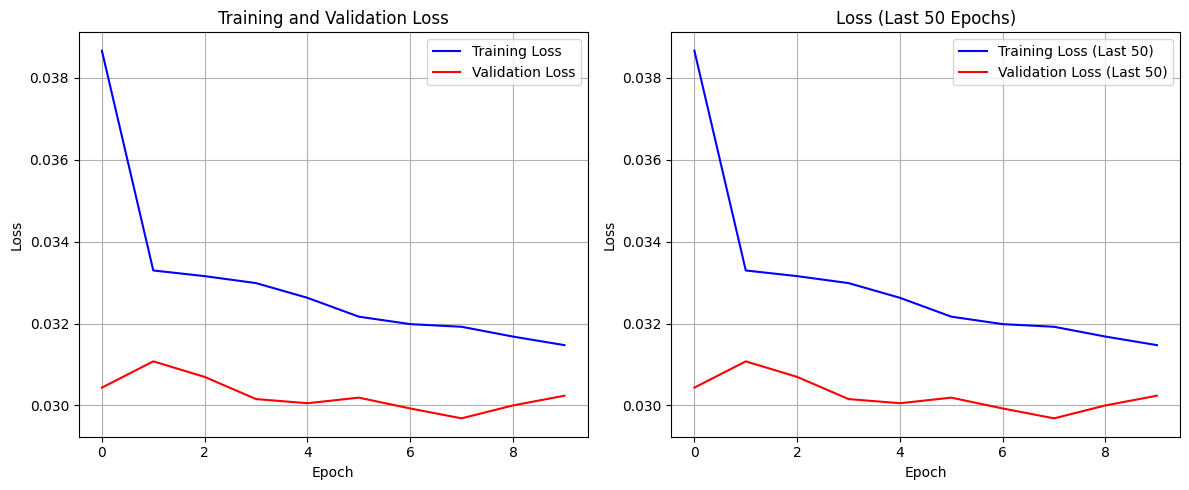

Final Training Loss: 0.031472
Final Validation Loss: 0.030236


In [72]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(test_losses, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses[-50:], label='Training Loss (Last 50)', color='blue')
plt.plot(test_losses[-50:], label='Validation Loss (Last 50)', color='red')
plt.title('Loss (Last 50 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.6f}")
print(f"Final Validation Loss: {test_losses[-1]:.6f}")


In [ ]:
def evaluate_model_per_sample(model, test_loader, test_scalers, device):
    """
    Evaluate the model with per-sample denormalization
    Since each sample was normalized with its own min/max, we need to 
    denormalize each prediction using its corresponding scaler info
    """
    model.eval()
    all_predictions = []
    all_actuals = []
    
    with torch.no_grad():
        for batch_idx, (batch_X, batch_y) in enumerate(test_loader):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            
            all_predictions.extend(outputs.cpu().numpy())
            all_actuals.extend(batch_y.cpu().numpy())
    
    # Convert to numpy arrays
    predictions_norm = np.array(all_predictions)
    actuals_norm = np.array(all_actuals)
    
    print(f"Normalized predictions range: [{predictions_norm.min():.3f}, {predictions_norm.max():.3f}]")
    print(f"Normalized actuals range: [{actuals_norm.min():.3f}, {actuals_norm.max():.3f}]")
    
    # Denormalize using per-sample scalers
    predictions_denorm = np.zeros_like(predictions_norm)
    actuals_denorm = np.zeros_like(actuals_norm)
    
    print("Denormalizing predictions using per-sample scalers...")
    for i in range(len(predictions_norm)):
        scaler_info = test_scalers[i]
        price_min = scaler_info['price_min']
        price_max = scaler_info['price_max']
        
        # Denormalize predictions and actuals using the same price range
        if price_max > price_min:
            predictions_denorm[i] = predictions_norm[i] * (price_max - price_min) + price_min
            actuals_denorm[i] = actuals_norm[i] * (price_max - price_min) + price_min
        else:
            # Edge case: no price variation in the P candles
            predictions_denorm[i] = [price_min, price_min]
            actuals_denorm[i] = [price_min, price_min]
    
    print(f"Denormalized predictions range: [{predictions_denorm.min():.4f}, {predictions_denorm.max():.4f}]")
    print(f"Denormalized actuals range: [{actuals_denorm.min():.4f}, {actuals_denorm.max():.4f}]")
    
    return predictions_denorm, actuals_denorm

# Evaluate the model with corrected function
print("Evaluating model with per-sample denormalization...")
predictions, actuals = evaluate_model_per_sample(model, test_loader, test_scalers, device)

print(f"\nFinal shapes:")
print(f"Predictions shape: {predictions.shape}")
print(f"Actuals shape: {actuals.shape}")

# Calculate metrics (same as before)
min_mse = mean_squared_error(actuals[:, 0], predictions[:, 0])
max_mse = mean_squared_error(actuals[:, 1], predictions[:, 1])
min_mae = mean_absolute_error(actuals[:, 0], predictions[:, 0])
max_mae = mean_absolute_error(actuals[:, 1], predictions[:, 1])

print(f"\nEvaluation Metrics:")
print(f"Min Price - MSE: {min_mse:.6f}, MAE: {min_mae:.6f}")
print(f"Max Price - MSE: {max_mse:.6f}, MAE: {max_mae:.6f}")

# Calculate percentage errors (with safety check for division by zero)
def safe_mape(actual, predicted):
    """Calculate MAPE with safety check for zero values"""
    mask = actual != 0
    if mask.sum() == 0:
        return 0.0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

min_mape = safe_mape(actuals[:, 0], predictions[:, 0])
max_mape = safe_mape(actuals[:, 1], predictions[:, 1])

print(f"Min Price MAPE: {min_mape:.2f}%")
print(f"Max Price MAPE: {max_mape:.2f}%")

# Additional analysis: check if predictions make sense
print(f"\nSanity Checks:")
print(f"Average actual min price: {actuals[:, 0].mean():.4f}")
print(f"Average predicted min price: {predictions[:, 0].mean():.4f}")
print(f"Average actual max price: {actuals[:, 1].mean():.4f}")
print(f"Average predicted max price: {predictions[:, 1].mean():.4f}")

# Check if predicted min < predicted max (should be true most of the time)
valid_predictions = predictions[:, 0] <= predictions[:, 1]
print(f"Predictions where min <= max: {valid_predictions.sum()}/{len(valid_predictions)} ({valid_predictions.mean()*100:.1f}%)")

Evaluating model...
Predictions shape: (59937, 2)
Actuals shape: (59937, 2)

Evaluation Metrics:
Min Price - MSE: 804995.062500, MAE: 484.476593
Max Price - MSE: 568130.000000, MAE: 459.294250
Min Price MAPE: 88.34%
Max Price MAPE: 15.67%


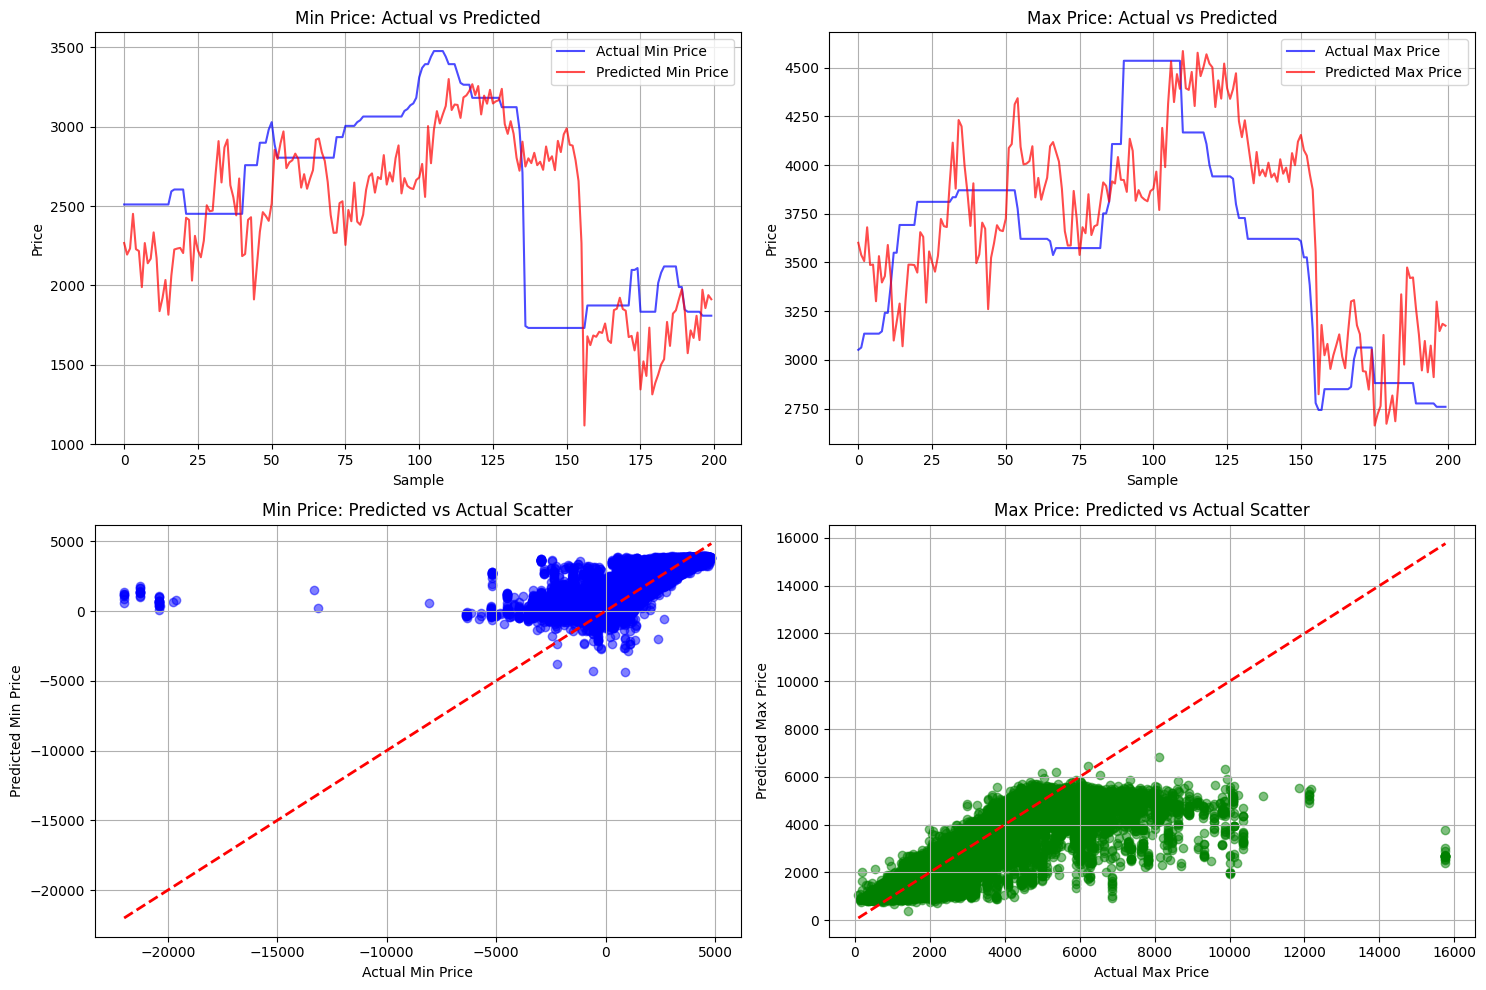


Sample Predictions (first 5):
Index | Actual Min | Pred Min | Actual Max | Pred Max | Min Error% | Max Error%
--------------------------------------------------------------------------------
    0 | 2510.5454 | 2267.5549 | 3051.3433 | 3600.9751 |     9.68% |    18.01%
    1 | 2510.5454 | 2194.6763 | 3063.2168 | 3538.4846 |    12.58% |    15.52%
    2 | 2510.5454 | 2233.1584 | 3134.4583 | 3507.1409 |    11.05% |    11.89%
    3 | 2510.5454 | 2451.4653 | 3134.4583 | 3680.5637 |     2.35% |    17.42%
    4 | 2510.5454 | 2228.8398 | 3134.4583 | 3487.0649 |    11.22% |    11.25%


In [74]:
# Visualize predictions vs actual values
plt.figure(figsize=(15, 10))

# Plot sample of predictions (first 200 points for clarity)
sample_size = min(200, len(predictions))
x_axis = range(sample_size)

# Min price predictions
plt.subplot(2, 2, 1)
plt.plot(x_axis, actuals[:sample_size, 0], label='Actual Min Price', color='blue', alpha=0.7)
plt.plot(x_axis, predictions[:sample_size, 0], label='Predicted Min Price', color='red', alpha=0.7)
plt.title('Min Price: Actual vs Predicted')
plt.xlabel('Sample')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Max price predictions
plt.subplot(2, 2, 2)
plt.plot(x_axis, actuals[:sample_size, 1], label='Actual Max Price', color='blue', alpha=0.7)
plt.plot(x_axis, predictions[:sample_size, 1], label='Predicted Max Price', color='red', alpha=0.7)
plt.title('Max Price: Actual vs Predicted')
plt.xlabel('Sample')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Scatter plot for min price
plt.subplot(2, 2, 3)
plt.scatter(actuals[:, 0], predictions[:, 0], alpha=0.5, color='blue')
plt.plot([actuals[:, 0].min(), actuals[:, 0].max()], 
         [actuals[:, 0].min(), actuals[:, 0].max()], 'r--', lw=2)
plt.xlabel('Actual Min Price')
plt.ylabel('Predicted Min Price')
plt.title('Min Price: Predicted vs Actual Scatter')
plt.grid(True)

# Scatter plot for max price
plt.subplot(2, 2, 4)
plt.scatter(actuals[:, 1], predictions[:, 1], alpha=0.5, color='green')
plt.plot([actuals[:, 1].min(), actuals[:, 1].max()], 
         [actuals[:, 1].min(), actuals[:, 1].max()], 'r--', lw=2)
plt.xlabel('Actual Max Price')
plt.ylabel('Predicted Max Price')
plt.title('Max Price: Predicted vs Actual Scatter')
plt.grid(True)

plt.tight_layout()
plt.show()

# Print sample predictions
print("\nSample Predictions (first 5):")
print("Index | Actual Min | Pred Min | Actual Max | Pred Max | Min Error% | Max Error%")
print("-" * 80)
for i in range(min(5, len(predictions))):
    actual_min, actual_max = actuals[i]
    pred_min, pred_max = predictions[i]
    min_error = abs((actual_min - pred_min) / actual_min) * 100
    max_error = abs((actual_max - pred_max) / actual_max) * 100
    print(f"{i:5d} | {actual_min:8.4f} | {pred_min:8.4f} | {actual_max:8.4f} | {pred_max:8.4f} | {min_error:8.2f}% | {max_error:8.2f}%")


In [ ]:
# Prediction function for per-sample normalized model
def predict_future_prices_per_sample(model, recent_data, device, p_candles=30):
    """
    Make predictions using per-sample normalization approach
    
    Args:
        model: Trained model (expects per-sample normalized inputs)
        recent_data: Recent OHLCV data - needs at least P candles
        device: PyTorch device
        p_candles: Number of previous candles to use
        
    Returns:
        Predicted min and max prices (denormalized to actual price levels)
    """
    if isinstance(recent_data, pd.DataFrame):
        features = ['Open', 'High', 'Low', 'Close', 'Volume']
        recent_data = recent_data[features].values
    
    if len(recent_data) < p_candles:
        raise ValueError(f"Need at least {p_candles} candles for prediction")
    
    # Take the last P candles
    input_data = recent_data[-p_candles:]  # Shape: (P, 5)
    
    # Separate OHLC and Volume
    input_prices = input_data[:, :4]  # OHLC
    input_volume = input_data[:, 4:5]  # Volume
    
    # Get normalization parameters from the input data itself
    price_min = input_prices.min()
    price_max = input_prices.max()
    volume_min = input_volume.min()
    volume_max = input_volume.max()
    
    # Normalize using local min/max (same as training)
    if price_max > price_min:
        input_prices_norm = (input_prices - price_min) / (price_max - price_min)
    else:
        input_prices_norm = np.zeros_like(input_prices)
    
    if volume_max > volume_min:
        input_volume_norm = (input_volume - volume_min) / (volume_max - volume_min)
    else:
        input_volume_norm = np.ones_like(input_volume) * 0.5
    
    # Combine normalized features
    input_normalized = np.concatenate([input_prices_norm, input_volume_norm], axis=1)
    input_tensor = torch.FloatTensor(input_normalized).unsqueeze(0).to(device)  # Add batch dim
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        prediction_norm = model(input_tensor).cpu().numpy()[0]  # Remove batch dim
    
    # Denormalize prediction using the SAME local price range
    if price_max > price_min:
        prediction_actual = prediction_norm * (price_max - price_min) + price_min
    else:
        prediction_actual = np.array([price_min, price_min])
    
    return prediction_actual, {
        'price_range': price_max - price_min,
        'price_min': price_min,
        'price_max': price_max,
        'normalized_prediction': prediction_norm
    }

print("✅ Per-sample prediction function ready")